АНАЛИЗ ДАТАСЕТА: dataset_01
=== dataset_01 ===
Размер: (12000, 9)

Первые 5 строк:
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056  61.833444 -0.022466  -42.631335   3.107154   

         f06        f07       f08  
0 -12.291287  -6.836847 -0.504094  
1  34.316967 -49.468873  0.390356  
2  25.892951  44.595250  0.325893  
3   2.014316 -39.930582  0.139297  
4  -5.471054   7.001149  0.131213  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 no

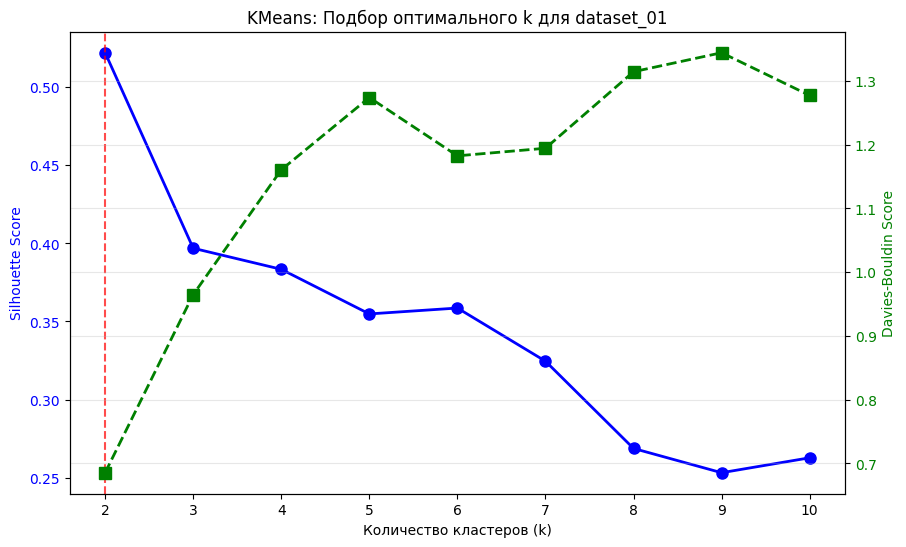

Лучшее k: 2
Silhouette: 0.522
Davies-Bouldin: 0.685

--- DBSCAN ---


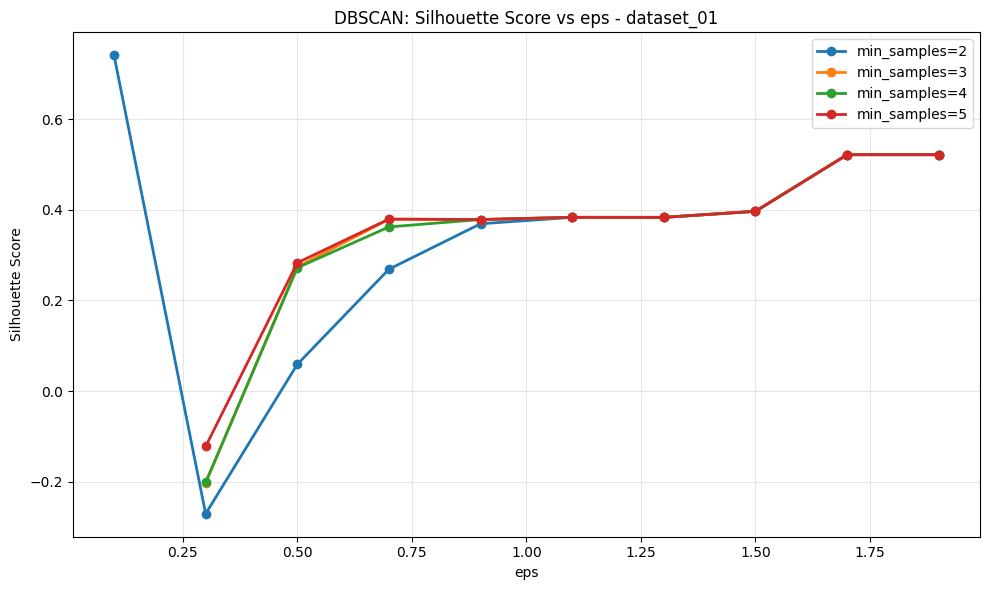

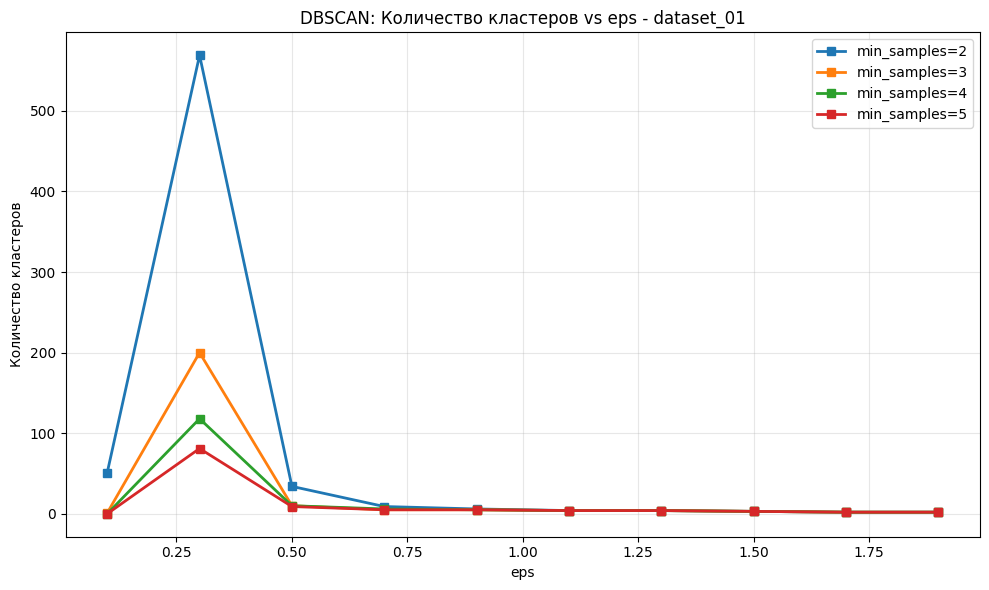

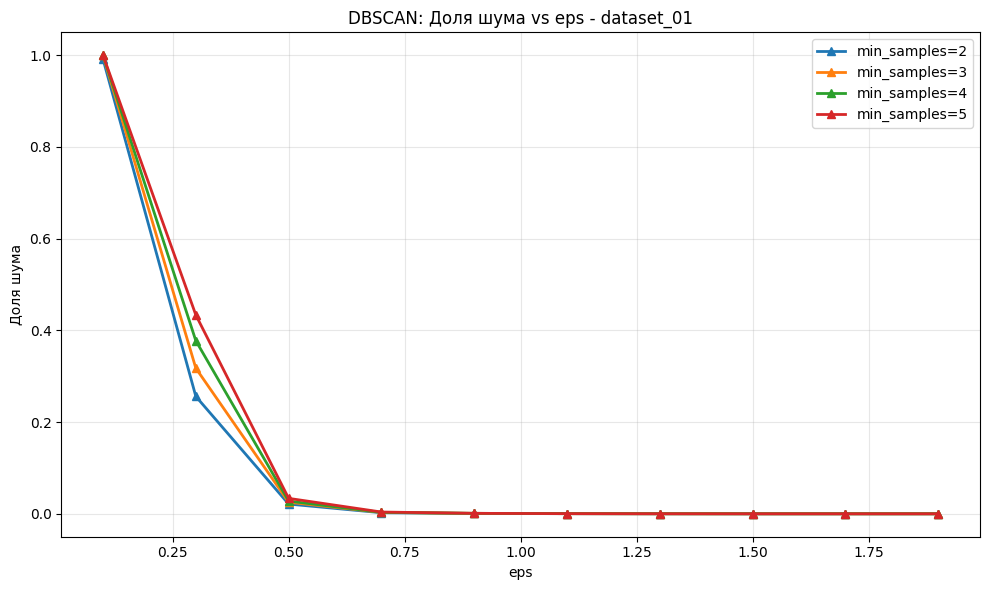

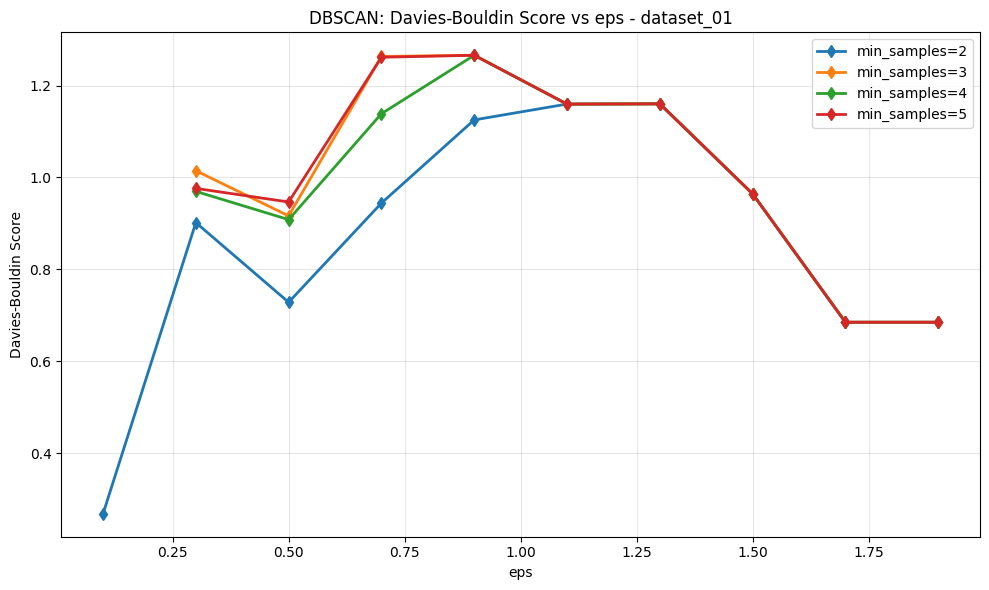

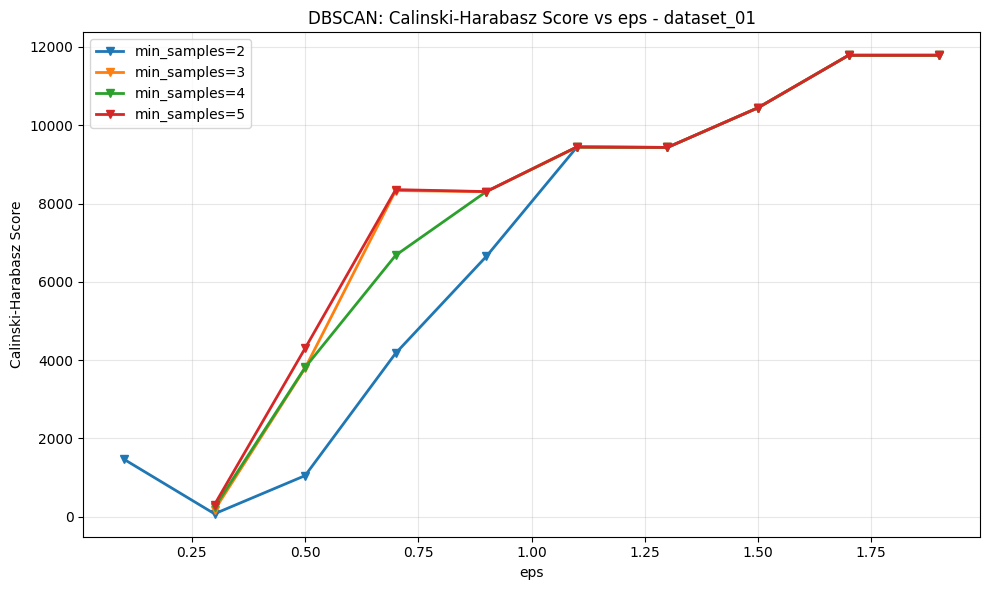

Лучшие параметры: eps=0.1, min_samples=2
Silhouette: 0.741
Доля шума: 0.991

--- СРАВНЕНИЕ МЕТОДОВ ---
Лучший метод: DBSCAN (silhouette=0.741)

--- ВИЗУАЛИЗАЦИЯ ---


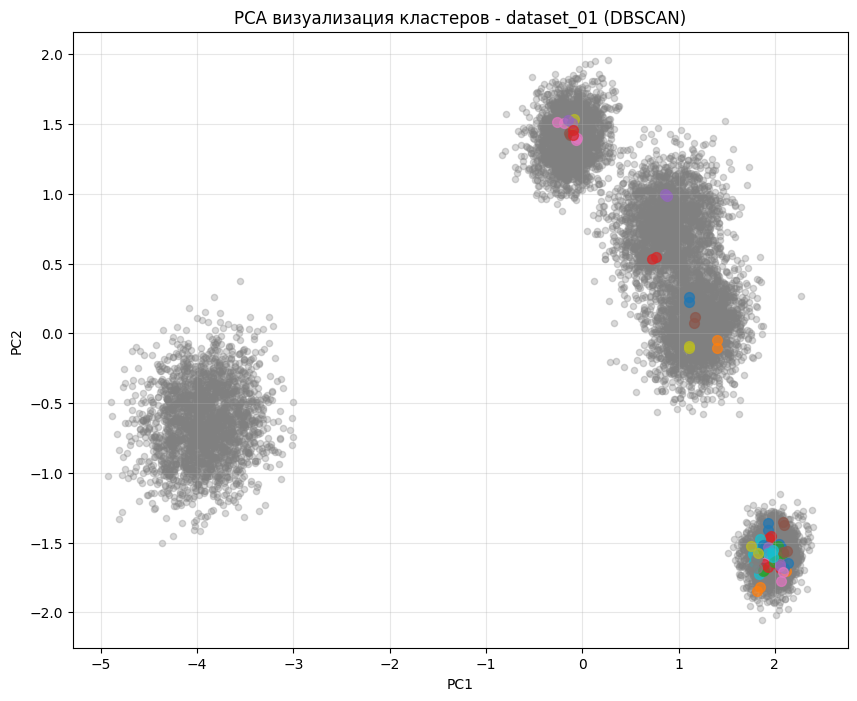

АНАЛИЗ ДАТАСЕТА: dataset_02
=== dataset_02 ===
Размер: (8000, 4)

Первые 5 строк:
   sample_id        x1        x2    z_noise
0          0  0.098849 -1.846034  21.288122
1          1 -1.024516  1.829616   6.072952
2          2 -1.094178 -0.158545 -18.938342
3          3 -1.612808 -1.565844 -11.629462
4          4  1.659901 -2.133292   1.895472

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB
None

Пропуски:
sample_id    0
x1           0
x2           0
z_noise      0
dtype: int64

Основные статистики:
        sample_id           x1           x2      z_noise
count  8000.00000  8000.000000  8000.000000  8000.000000
mean   39

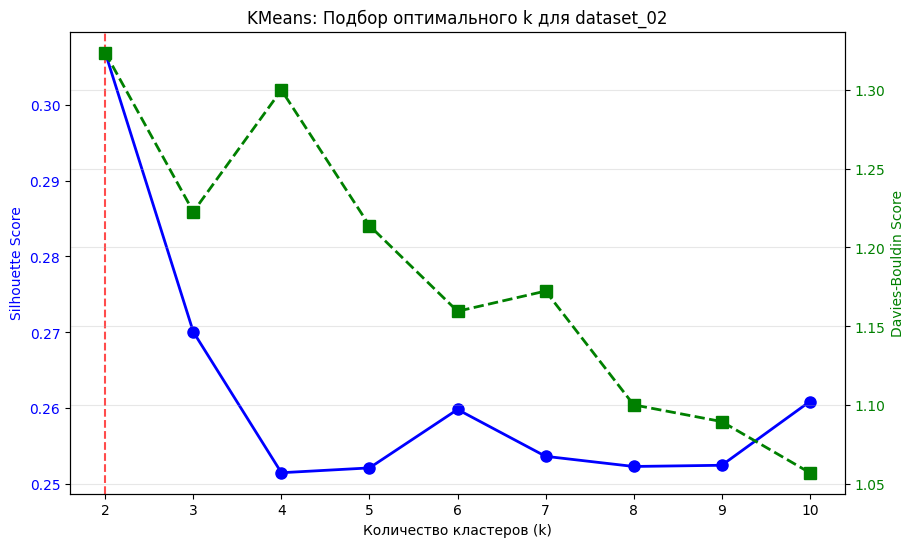

Лучшее k: 2
Silhouette: 0.307
Davies-Bouldin: 1.323

--- DBSCAN ---


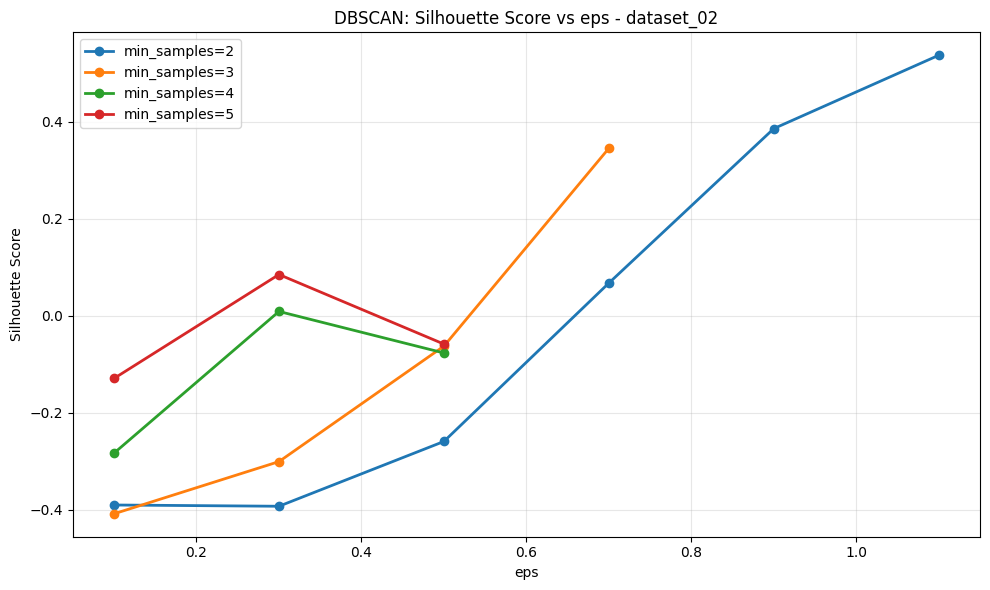

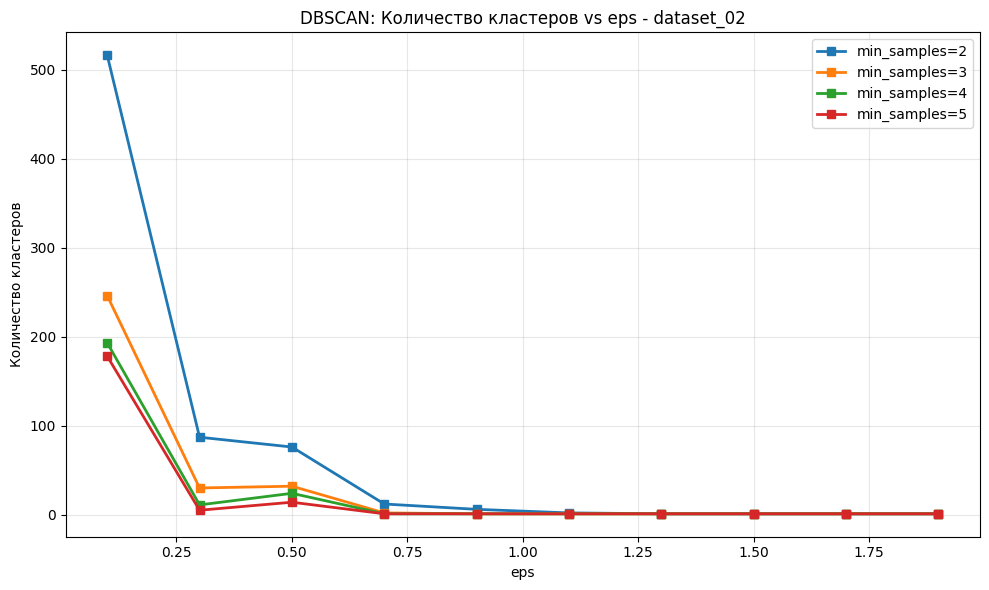

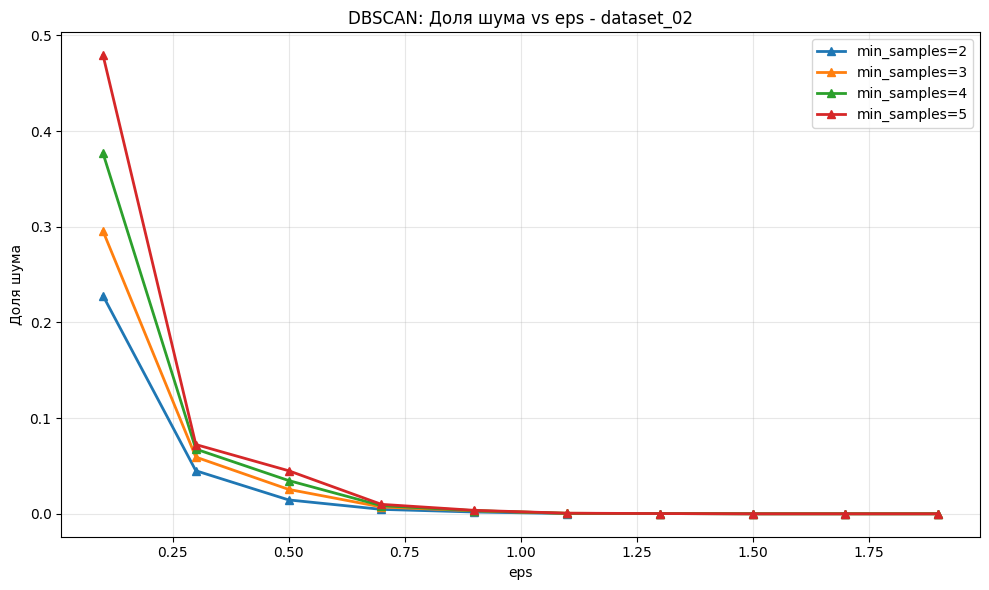

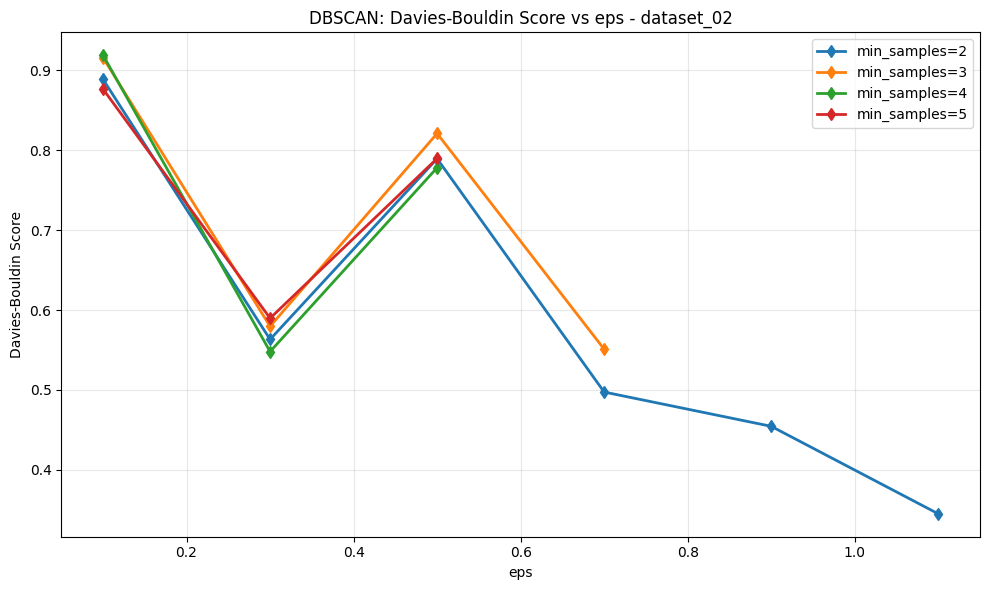

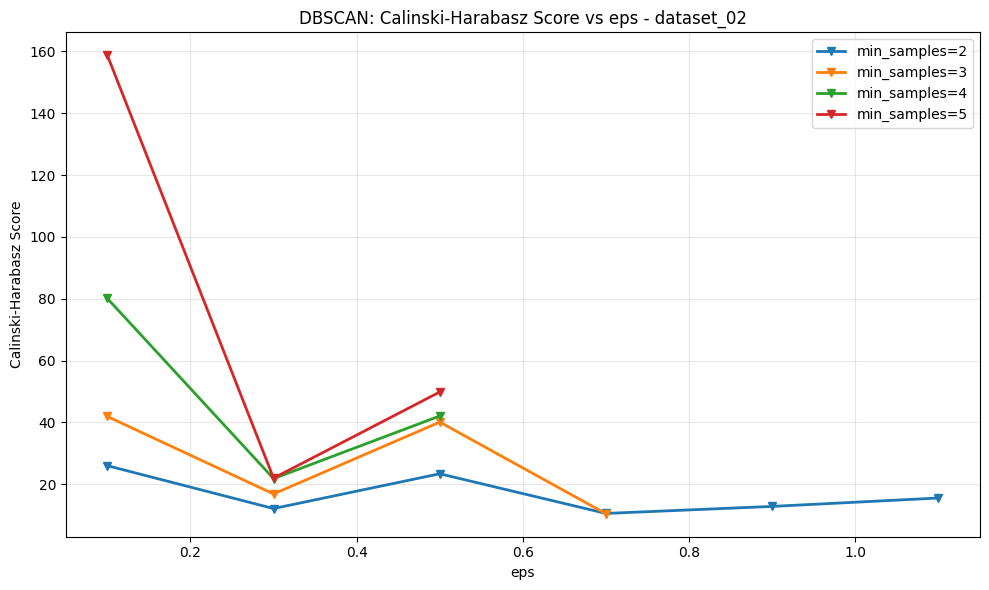

Лучшие параметры: eps=1.1, min_samples=2
Silhouette: 0.537
Доля шума: 0.000

--- СРАВНЕНИЕ МЕТОДОВ ---
Лучший метод: DBSCAN (silhouette=0.537)

--- ВИЗУАЛИЗАЦИЯ ---


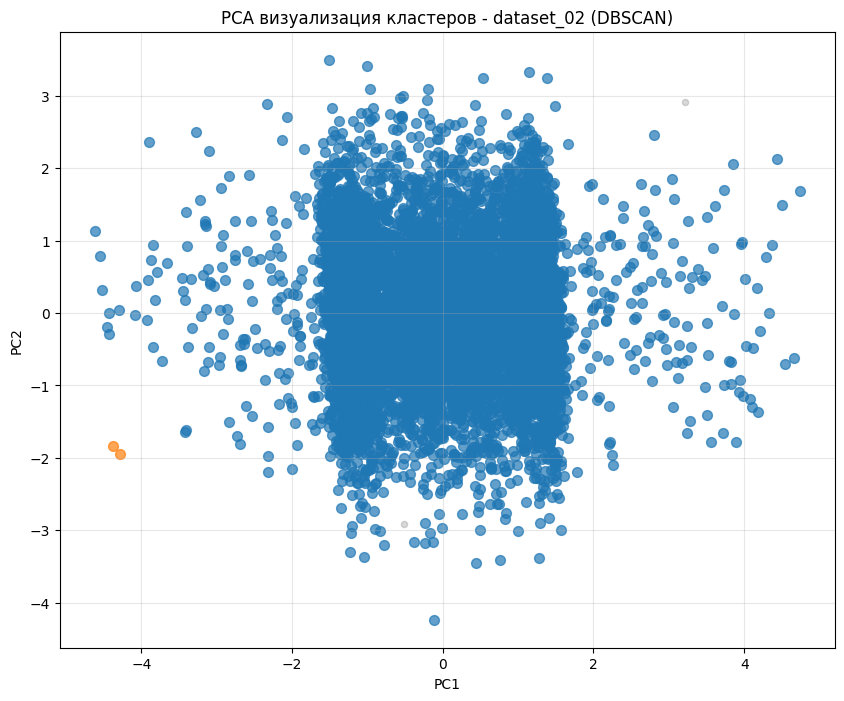

АНАЛИЗ ДАТАСЕТА: dataset_03
=== dataset_03 ===
Размер: (15000, 5)

Первые 5 строк:
   sample_id        x1        x2    f_corr   f_noise
0          0 -2.710470  4.997107 -1.015703  0.718508
1          1  8.730238 -8.787416  3.953063 -1.105349
2          2 -1.079600 -2.558708  0.976628 -3.605776
3          3  6.854042  1.560181  1.760614 -1.230946
4          4  9.963812 -8.869921  2.966583  0.915899

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB
None

Пропуски:
sample_id    0
x1           0
x2           0
f_corr       0
f_noise      0
dtype: int64

Основные статистики:
          s

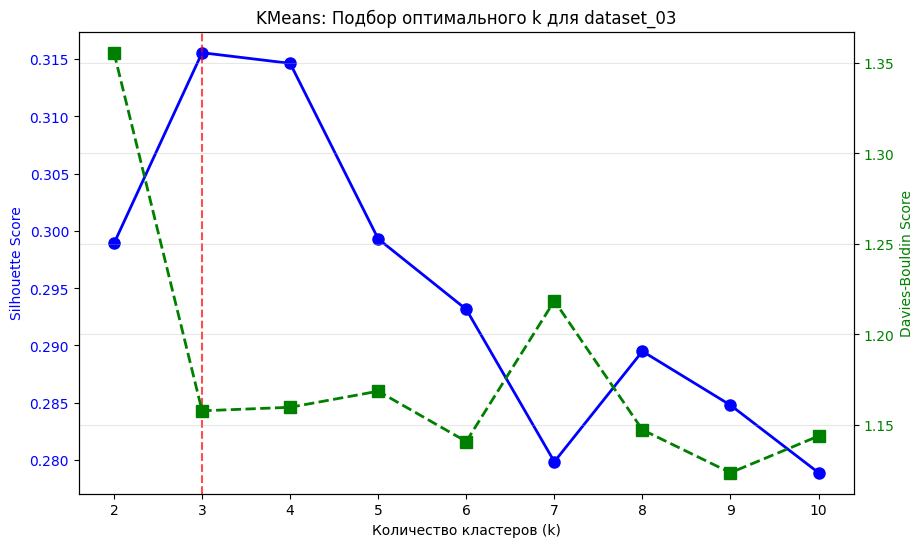

Лучшее k: 3
Silhouette: 0.316
Davies-Bouldin: 1.158

--- DBSCAN ---


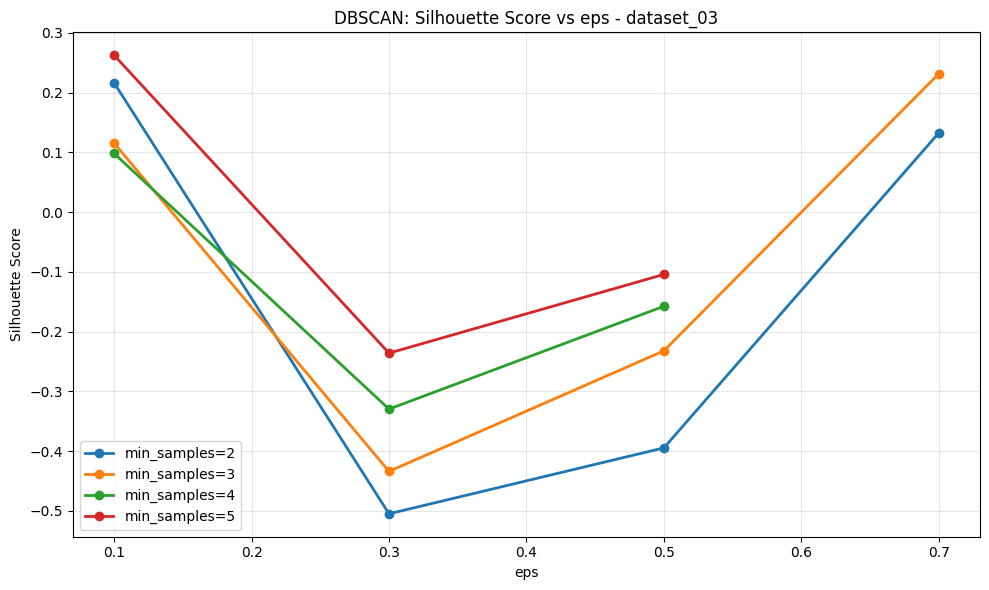

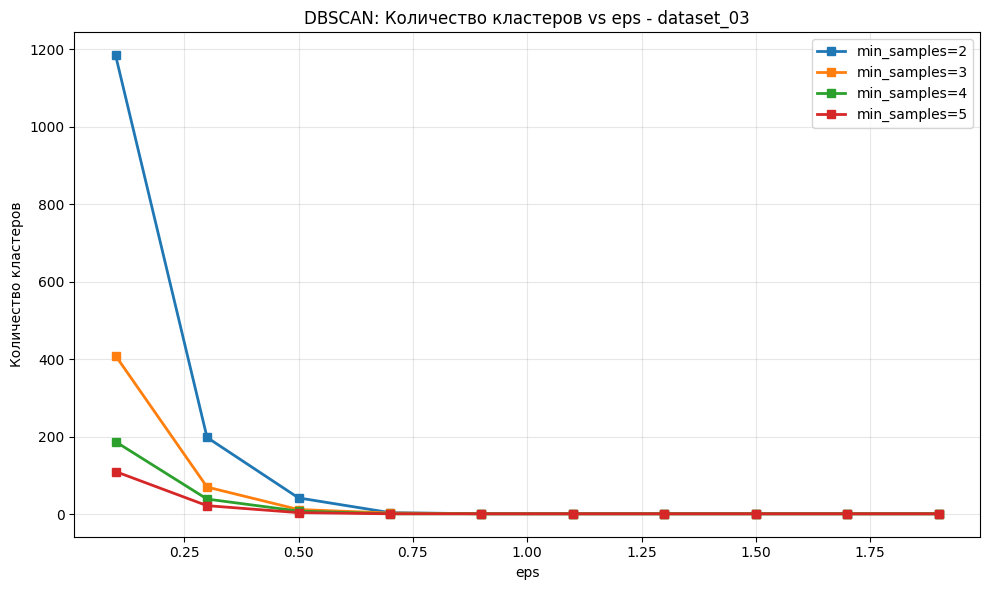

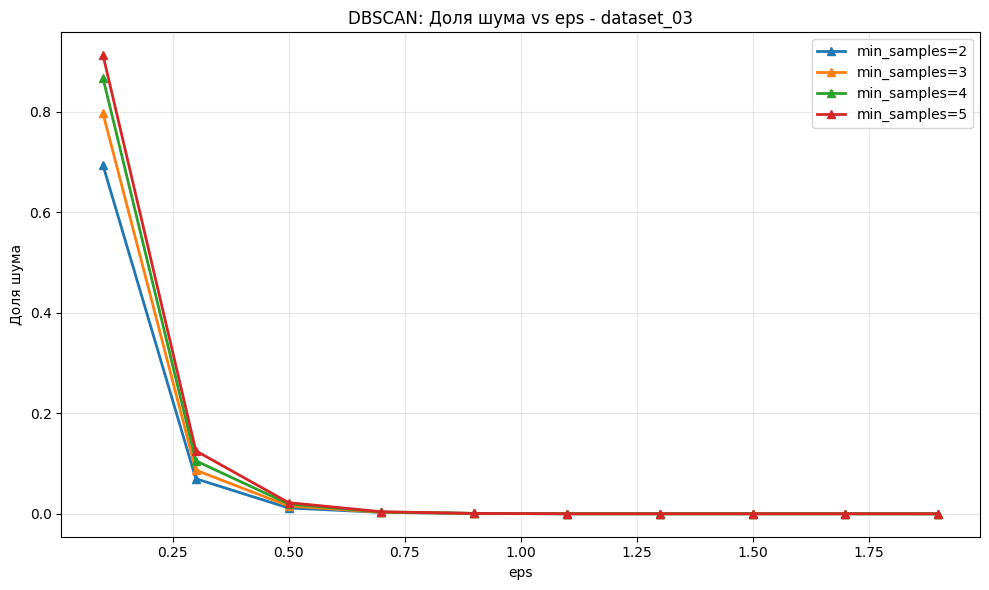

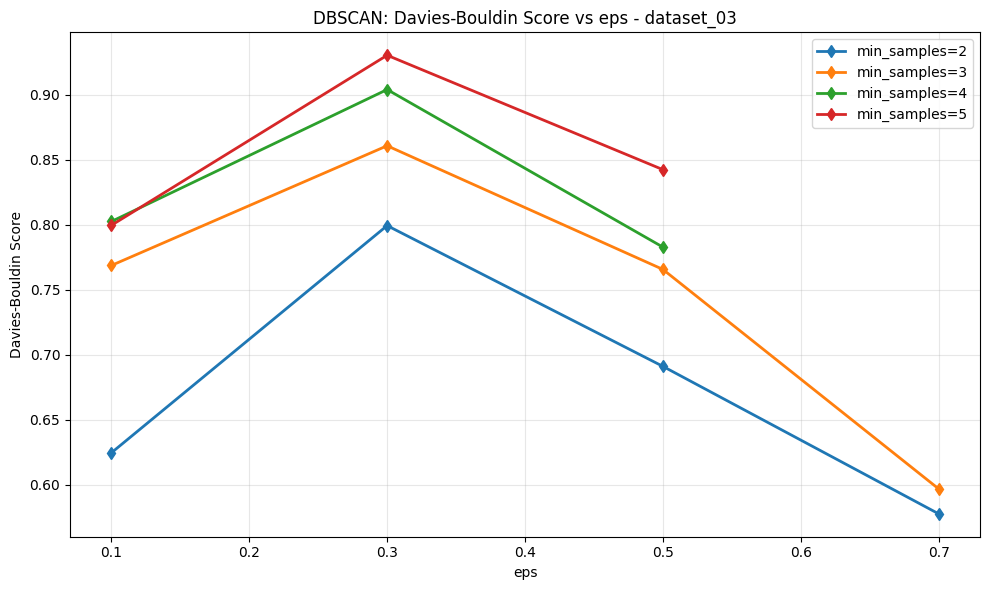

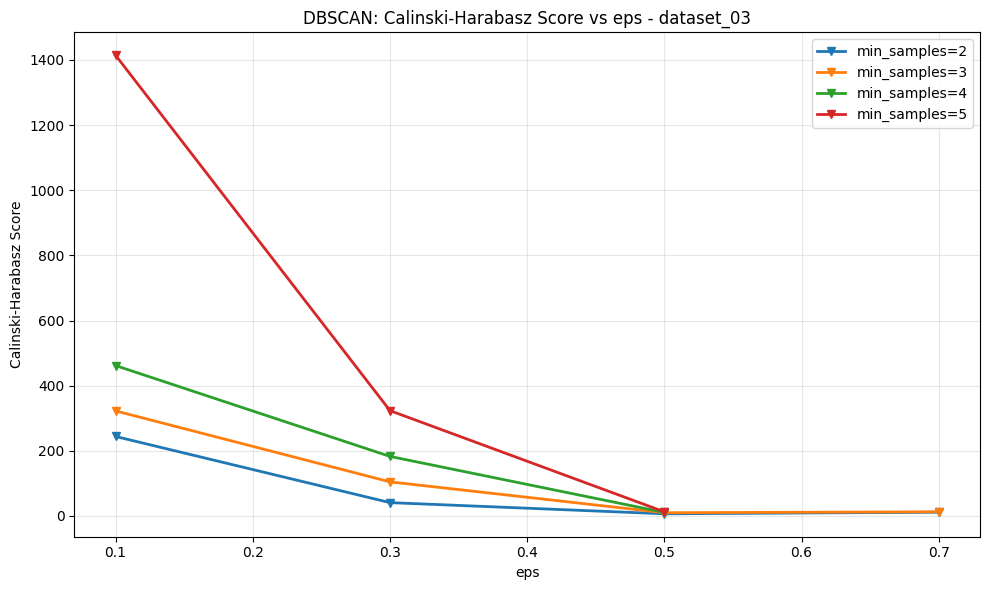

Лучшие параметры: eps=0.1, min_samples=5
Silhouette: 0.262
Доля шума: 0.912

--- СРАВНЕНИЕ МЕТОДОВ ---
Лучший метод: KMeans (silhouette=0.316)

--- ВИЗУАЛИЗАЦИЯ ---


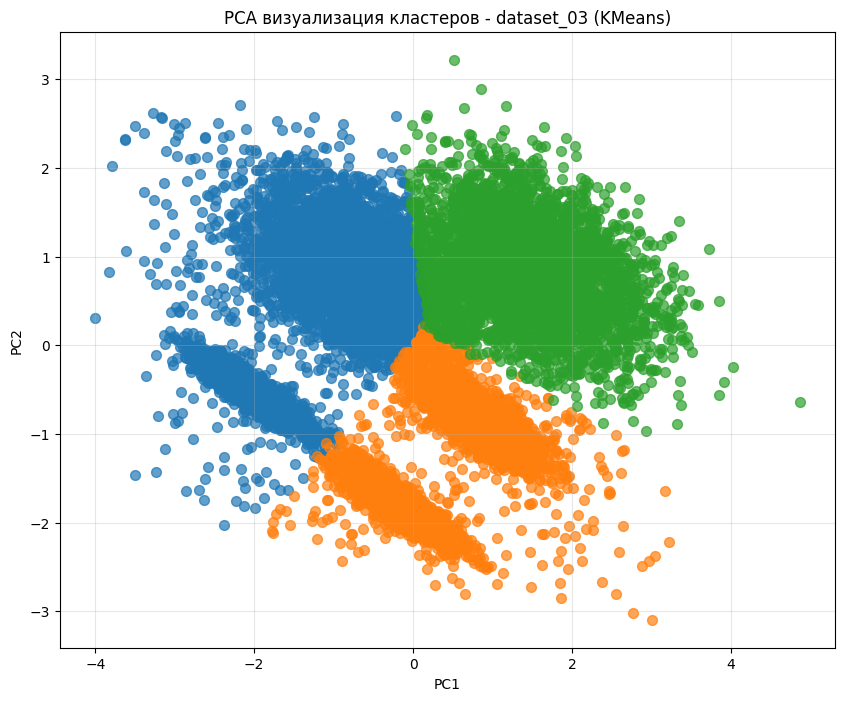

In [1]:
import json
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt


class DatasetAnalyzer:
    def __init__(self, dataset_name, file_path):
        self.dataset_name = dataset_name
        self.file_path = file_path
        self.df = None
        self.X = None
        self.sample_ids = None
        self.preprocessor = None
        self.X_scaled = None

    def load_and_analyze(self):
        self.df = pd.read_csv(self.file_path)

        # Сохраняем sample_id отдельно
        self.sample_ids = self.df['sample_id']
        self.X = self.df.drop('sample_id', axis=1)

        print(f"=== {self.dataset_name} ===")
        print(f"Размер: {self.df.shape}")
        print("\nПервые 5 строк:")
        print(self.df.head())
        print("\nИнформация о данных:")
        print(self.df.info())
        print("\nПропуски:")
        print(self.df.isnull().sum())
        print("\nОсновные статистики:")
        print(self.df.describe())

        return self.df

    def preprocess_data(self):
        # Проверяем типы признаков
        numeric_cols = self.X.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = self.X.select_dtypes(include=['object', 'category']).columns.tolist()

        print(f"\nЧисловые признаки: {len(numeric_cols)}")
        print(f"Категориальные признаки: {len(categorical_cols)}")

        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

        self.preprocessor = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

        self.X_scaled = self.preprocessor.fit_transform(self.X)
        print(f"\nДанные после препроцессинга: {self.X_scaled.shape}")

        return self.X_scaled

    def run_kmeans(self, k_range=range(2, 11), random_state=42):
        """Запуск KMeans с подбором k"""
        silhouette_scores = []
        db_scores = []
        ch_scores = []
        models = []

        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            labels = kmeans.fit_predict(self.X_scaled)

            # Рассчитываем метрики только если есть более 1 кластера
            if len(np.unique(labels)) > 1:
                sil_score = silhouette_score(self.X_scaled, labels)
                db_score = davies_bouldin_score(self.X_scaled, labels)
                ch_score = calinski_harabasz_score(self.X_scaled, labels)
            else:
                sil_score = db_score = ch_score = np.nan

            silhouette_scores.append(sil_score)
            db_scores.append(db_score)
            ch_scores.append(ch_score)
            models.append(kmeans)

        # Находим лучший k по silhouette score
        best_idx = np.nanargmax(silhouette_scores)
        best_k = k_range[best_idx]
        best_model = models[best_idx]

        fig, ax1 = plt.subplots(figsize=(10, 6))

        ax1.set_xlabel('Количество кластеров (k)')
        ax1.set_ylabel('Silhouette Score', color='blue')
        ax1.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.axvline(x=best_k, color='r', linestyle='--', alpha=0.7)

        ax2 = ax1.twinx()
        ax2.set_ylabel('Davies-Bouldin Score', color='green')
        ax2.plot(k_range, db_scores, 's--', linewidth=2, markersize=8, color='green')
        ax2.tick_params(axis='y', labelcolor='green')

        plt.title(f'KMeans: Подбор оптимального k для {self.dataset_name}')
        plt.grid(True, alpha=0.3)

        plt.savefig(f'artifacts/figures/{self.dataset_name}_kmeans_scores.png',
                   bbox_inches='tight', dpi=150)
        plt.show()

        return {
            'best_k': best_k,
            'best_model': best_model,
            'scores': {
                'silhouette': silhouette_scores,
                'davies_bouldin': db_scores,
                'calinski_harabasz': ch_scores
            }
        }

    def run_dbscan(self, eps_range=np.arange(0.1, 2.0, 0.1),min_samples_range=[2, 3, 4, 5]):
        best_score = -1
        best_params = None
        best_model = None
        best_labels = None

        results = []

        for eps in eps_range:
            for min_samples in min_samples_range:
                dbscan = DBSCAN(eps=eps, min_samples=min_samples)
                labels = dbscan.fit_predict(self.X_scaled)

                # Рассчитываем метрики только для нешумовых точек
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                noise_ratio = np.sum(labels == -1) / len(labels) if len(labels) > 0 else 0

                if n_clusters > 1:
                    # Используем только нешумовые точки для расчета метрик
                    non_noise_mask = labels != -1
                    if np.sum(non_noise_mask) > 1:
                        X_non_noise = self.X_scaled[non_noise_mask]
                        labels_non_noise = labels[non_noise_mask]

                        sil_score = silhouette_score(X_non_noise, labels_non_noise)
                        db_score = davies_bouldin_score(X_non_noise, labels_non_noise)
                        ch_score = calinski_harabasz_score(X_non_noise, labels_non_noise)
                    else:
                        sil_score = db_score = ch_score = np.nan
                else:
                    sil_score = db_score = ch_score = np.nan

                results.append({
                    'eps': eps,
                    'min_samples': min_samples,
                    'silhouette': sil_score,
                    'davies_bouldin': db_score,
                    'calinski_harabasz': ch_score,
                    'n_clusters': n_clusters,
                    'noise_ratio': noise_ratio
                })

                if not np.isnan(sil_score) and sil_score > best_score:
                    best_score = sil_score
                    best_params = {'eps': eps, 'min_samples': min_samples}
                    best_model = dbscan
                    best_labels = labels

        results_df = pd.DataFrame(results)

        # Визуализация - отдельные графики
        if len(results_df) > 0:
            # График 1: silhouette vs eps для разных min_samples
            plt.figure(figsize=(10, 6))
            for min_samples in min_samples_range:
                subset = results_df[results_df['min_samples'] == min_samples]
                plt.plot(subset['eps'], subset['silhouette'],
                        marker='o', linewidth=2, label=f'min_samples={min_samples}')
            plt.xlabel('eps')
            plt.ylabel('Silhouette Score')
            plt.title(f'DBSCAN: Silhouette Score vs eps - {self.dataset_name}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'artifacts/figures/{self.dataset_name}_dbscan_silhouette.png',
                       bbox_inches='tight', dpi=150)
            plt.show()

            # График 2: количество кластеров vs eps
            plt.figure(figsize=(10, 6))
            for min_samples in min_samples_range:
                subset = results_df[results_df['min_samples'] == min_samples]
                plt.plot(subset['eps'], subset['n_clusters'],
                        marker='s', linewidth=2, label=f'min_samples={min_samples}')
            plt.xlabel('eps')
            plt.ylabel('Количество кластеров')
            plt.title(f'DBSCAN: Количество кластеров vs eps - {self.dataset_name}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'artifacts/figures/{self.dataset_name}_dbscan_n_clusters.png',
                       bbox_inches='tight', dpi=150)
            plt.show()

            # График 3: доля шума vs eps
            plt.figure(figsize=(10, 6))
            for min_samples in min_samples_range:
                subset = results_df[results_df['min_samples'] == min_samples]
                plt.plot(subset['eps'], subset['noise_ratio'],
                        marker='^', linewidth=2, label=f'min_samples={min_samples}')
            plt.xlabel('eps')
            plt.ylabel('Доля шума')
            plt.title(f'DBSCAN: Доля шума vs eps - {self.dataset_name}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'artifacts/figures/{self.dataset_name}_dbscan_noise_ratio.png',
                       bbox_inches='tight', dpi=150)
            plt.show()

            # График 4: Davies-Bouldin vs eps
            plt.figure(figsize=(10, 6))
            for min_samples in min_samples_range:
                subset = results_df[results_df['min_samples'] == min_samples]
                plt.plot(subset['eps'], subset['davies_bouldin'],
                        marker='d', linewidth=2, label=f'min_samples={min_samples}')
            plt.xlabel('eps')
            plt.ylabel('Davies-Bouldin Score')
            plt.title(f'DBSCAN: Davies-Bouldin Score vs eps - {self.dataset_name}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'artifacts/figures/{self.dataset_name}_dbscan_davies_bouldin.png',
                       bbox_inches='tight', dpi=150)
            plt.show()

            # График 5: Calinski-Harabasz vs eps
            plt.figure(figsize=(10, 6))
            for min_samples in min_samples_range:
                subset = results_df[results_df['min_samples'] == min_samples]
                plt.plot(subset['eps'], subset['calinski_harabasz'],
                        marker='v', linewidth=2, label=f'min_samples={min_samples}')
            plt.xlabel('eps')
            plt.ylabel('Calinski-Harabasz Score')
            plt.title(f'DBSCAN: Calinski-Harabasz Score vs eps - {self.dataset_name}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'artifacts/figures/{self.dataset_name}_dbscan_calinski_harabasz.png',
                       bbox_inches='tight', dpi=150)
            plt.show()

        return {
            'best_params': best_params,
            'best_model': best_model,
            'best_labels': best_labels,
            'results': results_df
        }

    def visualize_clusters(self, labels, title_suffix=""):
        """Визуализация кластеров с помощью PCA"""
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(self.X_scaled)

        # Создаем DataFrame для удобства
        plot_df = pd.DataFrame({
            'PC1': X_pca[:, 0],
            'PC2': X_pca[:, 1],
            'cluster': labels
        })

        plt.figure(figsize=(10, 8))

        if -1 in labels:
            # Шумовые точки
            noise_mask = plot_df['cluster'] == -1
            if noise_mask.any():
                plt.scatter(plot_df.loc[noise_mask, 'PC1'],
                           plot_df.loc[noise_mask, 'PC2'],
                           c='gray', alpha=0.3, s=20, label='Шум')

            # Кластеры
            clusters = sorted([c for c in plot_df['cluster'].unique() if c != -1])
            for cluster in clusters:
                cluster_mask = plot_df['cluster'] == cluster
                plt.scatter(plot_df.loc[cluster_mask, 'PC1'],
                           plot_df.loc[cluster_mask, 'PC2'],
                           s=50, alpha=0.7)
        else:
            # Для KMeans и Agglomerative
            unique_clusters = sorted(plot_df['cluster'].unique())
            for cluster in unique_clusters:
                cluster_mask = plot_df['cluster'] == cluster
                plt.scatter(plot_df.loc[cluster_mask, 'PC1'],
                           plot_df.loc[cluster_mask, 'PC2'],
                           s=50, alpha=0.7)

        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title(f'PCA визуализация кластеров - {self.dataset_name} {title_suffix}')
        # plt.legend()
        plt.grid(True, alpha=0.3)

        plt.savefig(f'artifacts/figures/{self.dataset_name}_pca_clusters.png',
                   bbox_inches='tight', dpi=150)
        plt.show()

        return X_pca

    def calculate_metrics(self, labels, algorithm_name):
        """Расчет метрик качества кластеризации"""
        metrics = {}

        if len(np.unique(labels)) > 1:
            # Для DBSCAN с шумом считаем метрики только на нешумных точках
            if -1 in labels and algorithm_name == 'DBSCAN':
                non_noise_mask = labels != -1
                if np.sum(non_noise_mask) > 1:
                    X_non_noise = self.X_scaled[non_noise_mask]
                    labels_non_noise = labels[non_noise_mask]

                    metrics['silhouette'] = silhouette_score(X_non_noise, labels_non_noise)
                    metrics['davies_bouldin'] = davies_bouldin_score(X_non_noise, labels_non_noise)
                    metrics['calinski_harabasz'] = calinski_harabasz_score(X_non_noise, labels_non_noise)
                    metrics['noise_ratio'] = np.sum(labels == -1) / len(labels)
                else:
                    metrics['silhouette'] = metrics['davies_bouldin'] = metrics['calinski_harabasz'] = np.nan
                    metrics['noise_ratio'] = 1.0
            else:
                metrics['silhouette'] = silhouette_score(self.X_scaled, labels)
                metrics['davies_bouldin'] = davies_bouldin_score(self.X_scaled, labels)
                metrics['calinski_harabasz'] = calinski_harabasz_score(self.X_scaled, labels)
                if algorithm_name == 'DBSCAN':
                    metrics['noise_ratio'] = np.sum(labels == -1) / len(labels)
        else:
            metrics['silhouette'] = metrics['davies_bouldin'] = metrics['calinski_harabasz'] = np.nan
            if algorithm_name == 'DBSCAN':
                metrics['noise_ratio'] = 1.0 if -1 in labels else 0.0

        return metrics


def run_analysis():
    datasets = [
        ('dataset_01', 'S07-hw-dataset-01.csv'),
        ('dataset_02', 'S07-hw-dataset-02.csv'),
        ('dataset_03', 'S07-hw-dataset-03.csv')
    ]

    all_results = {}
    best_configs = {}

    for dataset_name, filename in datasets:
        print(f"АНАЛИЗ ДАТАСЕТА: {dataset_name}")

        analyzer = DatasetAnalyzer(dataset_name, f"data/{filename}")

        df = analyzer.load_and_analyze()

        X_scaled = analyzer.preprocess_data()

        print("\n--- KMeans ---")
        kmeans_results = analyzer.run_kmeans(k_range=range(2, 11))
        kmeans_labels = kmeans_results['best_model'].labels_
        kmeans_metrics = analyzer.calculate_metrics(kmeans_labels, 'KMeans')

        print(f"Лучшее k: {kmeans_results['best_k']}")
        print(f"Silhouette: {kmeans_metrics.get('silhouette', 'N/A'):.3f}")
        print(f"Davies-Bouldin: {kmeans_metrics.get('davies_bouldin', 'N/A'):.3f}")

        print("\n--- DBSCAN ---")
        dbscan_results = analyzer.run_dbscan(
            eps_range=np.arange(0.1, 2.0, 0.2),
            min_samples_range=[2, 3, 4, 5]
        )

        if dbscan_results['best_model'] is not None:
            dbscan_labels = dbscan_results['best_labels']
            dbscan_metrics = analyzer.calculate_metrics(dbscan_labels, 'DBSCAN')

            print(f"Лучшие параметры: eps={dbscan_results['best_params']['eps']}, "
                  f"min_samples={dbscan_results['best_params']['min_samples']}")
            print(f"Silhouette: {dbscan_metrics.get('silhouette', 'N/A'):.3f}")
            print(f"Доля шума: {dbscan_metrics.get('noise_ratio', 0):.3f}")
        else:
            dbscan_metrics = {'silhouette': np.nan, 'noise_ratio': 1.0}
            print("DBSCAN не нашел кластеров")

        print("\n--- СРАВНЕНИЕ МЕТОДОВ ---")

        # Сравниваем silhouette scores
        kmeans_sil = kmeans_metrics.get('silhouette', -1)
        dbscan_sil = dbscan_metrics.get('silhouette', -1)

        if not np.isnan(kmeans_sil) and (np.isnan(dbscan_sil) or kmeans_sil > dbscan_sil):
            best_method = 'KMeans'
            best_labels = kmeans_labels
            best_params = {'k': kmeans_results['best_k']}
            best_metrics = kmeans_metrics
            print(f"Лучший метод: KMeans (silhouette={kmeans_sil:.3f})")
        elif not np.isnan(dbscan_sil):
            best_method = 'DBSCAN'
            best_labels = dbscan_results['best_labels'] if dbscan_results['best_labels'] is not None else kmeans_labels
            best_params = dbscan_results['best_params']
            best_metrics = dbscan_metrics
            print(f"Лучший метод: DBSCAN (silhouette={dbscan_sil:.3f})")
        else:
            best_method = 'KMeans'
            best_labels = kmeans_labels
            best_params = {'k': kmeans_results['best_k']}
            best_metrics = kmeans_metrics
            print(f"Лучший метод: KMeans (по умолчанию)")

        print("\n--- ВИЗУАЛИЗАЦИЯ ---")
        analyzer.visualize_clusters(best_labels, f"({best_method})")

        all_results[dataset_name] = {
            'KMeans': {
                'metrics': kmeans_metrics,
                'params': {'k': kmeans_results['best_k']}
            },
            'DBSCAN': {
                'metrics': dbscan_metrics,
                'params': dbscan_results['best_params'] if dbscan_results['best_params'] else None
            },
            'best_method': best_method,
            'best_metrics': best_metrics
        }

        best_configs[dataset_name] = {
            'method': best_method,
            'params': best_params,
            'silhouette': best_metrics.get('silhouette', np.nan),
            'noise_ratio': best_metrics.get('noise_ratio', 0)
        }

        labels_df = pd.DataFrame({
            'sample_id': analyzer.sample_ids,
            'cluster_label': best_labels
        })
        labels_df.to_csv(f'artifacts/labels_hw07_{dataset_name}.csv', index=False)


    with open('artifacts/metrics_summary.json', 'w') as f:
        json.dump(all_results, f, indent=2, default=str)

    with open('artifacts/best_configs.json', 'w') as f:
        json.dump(best_configs, f, indent=2, default=str)

    return all_results, best_configs

results, configs = run_analysis()